In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np

In [2]:
tissues_df = pd.read_json('with_tissues_evaluations.json')
no_tissues_df = pd.read_json('evaluations.json')
sampling_lables = ['1','0.9','0.8','0.7','0.6','0.5','0.4','0.3','0.2','0.15','0.1','0.05','0.04','0.03','0.02','0.01']

In [3]:
run_index = 'run_1'
t_per_sample_accuracy = []
t_per_sample_mean_accuracy = []


for sample in tissues_df[run_index]:
    t_per_signature_accuracy = []
    for evaluation in sample.values():
        t_per_signature_accuracy.append(evaluation['accuracy'])

    t_per_sample_mean_accuracy.append(np.mean(t_per_signature_accuracy))
    t_per_sample_accuracy.append(t_per_signature_accuracy)

/home/massimo/Documents/stage/signature_inference/autogluon/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/massimo/Documents/stage/signature_inference/autogluon/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [4]:
run_index = 'run_1'
per_sample_accuracy = []
per_sample_mean_accuracy = []

for sample in no_tissues_df[run_index]:
    per_signature_accuracy = []
    for evaluation in sample.values():
        per_signature_accuracy.append(evaluation['accuracy'])
    per_sample_mean_accuracy.append(np.mean(per_signature_accuracy))
    per_sample_accuracy.append(per_signature_accuracy)

[0.8063104209484657, 0.80560630280886, 0.8049116997792489, 0.8052732739590466, 0.8037698865798883, 0.8016480170510767, 0.7998877217020625, 0.7954346502245563, 0.7925706021161599, 0.7910957600669859, 0.7895923726878278, 0.7810668341326023, 0.7794587805435026, 0.7791067214736999, nan, 0.769743853238943]
[0.852135190682804, 0.8491284159244877, 0.8512217401233153, 0.8501845931338964, 0.8465022455659583, 0.8472349090355479, 0.8420015985384787, 0.8364447743015904, 0.8281571134962318, 0.8246174925782142, 0.8155781380832758, 0.7999923879120039, 0.7945021694450783, 0.7882888026185577, 0.7790591459237265, 0.7650624191215648]
16


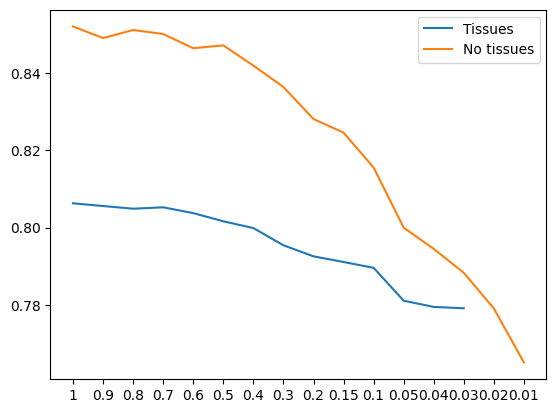

In [5]:
print(t_per_sample_mean_accuracy)
print(per_sample_mean_accuracy)
print(len(sampling_lables))

plt.figure()
plt.plot(sampling_lables, t_per_sample_mean_accuracy)
plt.plot(sampling_lables, per_sample_mean_accuracy)
plt.legend(['Tissues', 'No tissues'])